# Problema de clasificare

## 1. Definirea problemei


În această parte a proiectului este abordată o problemă de clasificare binară, folosind dataset-ul Breast Cancer Wisconsin Diagnostic. Scopul este construirea unor modele de machine learning capabile să clasifice o tumoră ca fiind benignă sau malignă, pe baza unor caracteristici numerice extrase din imagini medicale.

Variabila țintă este `target`, care poate lua două valori:
`0` = malignant
`1` = benign

Caracteristicile de intrare descriu proprietăți ale nucleilor celulari, precum raza, textura, perimetrul, aria, netezimea, compactitatea, concavitatea și alte măsuri statistice.

Am ales această problemă deoarece este o problemă clasică de clasificare binară, are relevanță practică și permite compararea clară a mai multor algoritmi de machine learning. Un astfel de model poate sprijini analiza preliminară a datelor medicale, fără a înlocui diagnosticul unui specialist.



In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from src.data import load_classification_data
from src.models import get_classification_models
from src.evaluation import (
    evaluate_classification_model,
    classification_results_to_dataframe
)

In [2]:
df, X, y, target_names = load_classification_data()

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
print("Dimensiune dataset:", df.shape)
print("Clase:", target_names)

df.info()

Dimensiune dataset: (569, 31)
Clase: {0: np.str_('malignant'), 1: np.str_('benign')}
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


## 2. Analiza exploratorie a datelor
În această secțiune analizăm structura dataset-ului, distribuția claselor, valorile lipsă, valorile extreme și relațiile dintre variabile. Scopul analizei exploratorii este înțelegerea datelor înainte de antrenarea modelelor de machine learning.


In [5]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [6]:
df["target"].value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [7]:
df["target"].value_counts(normalize=True)

target
1    0.627417
0    0.372583
Name: proportion, dtype: float64

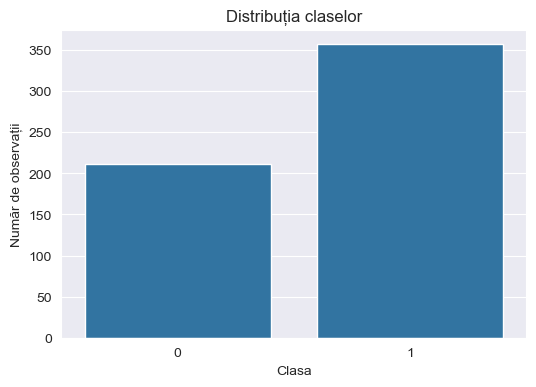

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="target")
plt.title("Distribuția claselor")
plt.xlabel("Clasa")
plt.ylabel("Număr de observații")
plt.show()

Distribuția claselor arată că dataset-ul este relativ echilibrat, deși clasa `1` are mai multe observații decât clasa `0`.
Acest lucru este important deoarece un dezechilibru foarte mare între clase ar putea afecta performanța modelelor, în special metrici precum acuratețea. În acest caz, dezechilibrul nu este sever, astfel încât putem continua folosind împărțirea stratificată a datelor.

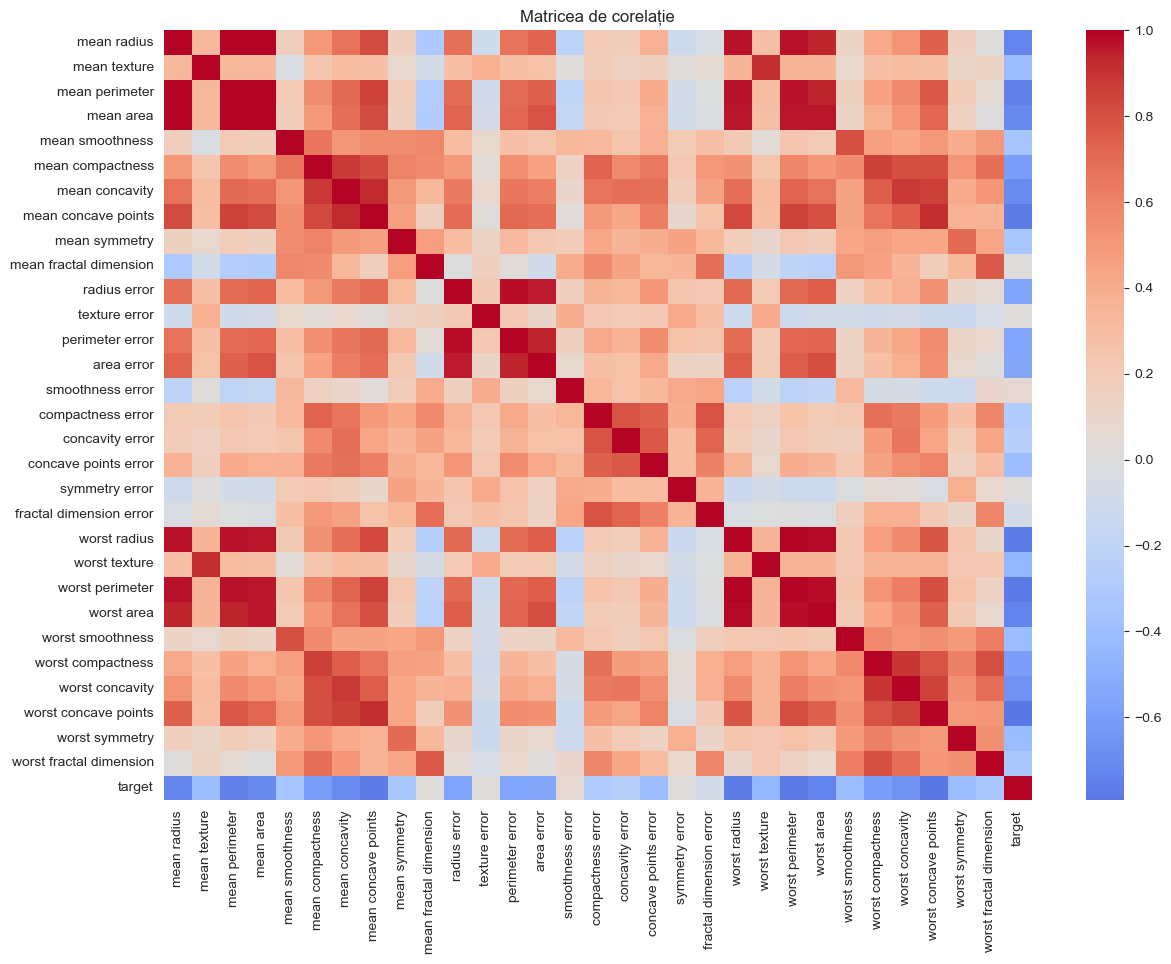

In [9]:
plt.figure(figsize=(14, 10))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matricea de corelație")
plt.show()

In [10]:
target_correlations = (
    df.corr(numeric_only=True)["target"]
    .sort_values(key=abs, ascending=False)
)

target_correlations.head(11)

target                  1.000000
worst concave points   -0.793566
worst perimeter        -0.782914
mean concave points    -0.776614
worst radius           -0.776454
mean perimeter         -0.742636
worst area             -0.733825
mean radius            -0.730029
mean area              -0.708984
mean concavity         -0.696360
worst concavity        -0.659610
Name: target, dtype: float64

# Matrice de corelație
Permite observarea relațiilor liniare dintre variabile. În special, corelația fiecărei caracteristici cu variabila țintă oferă o primă indicație asupra atributelor care pot fi utile pentru clasificare.

Totuși, corelația nu este suficientă pentru a stabili importanța reală a unei variabile, deoarece modelele de machine learning pot surprinde și relații neliniare sau interacțiuni între caracteristici.

In [11]:
top_features = target_correlations.drop("target").head(6).index.tolist()

top_features

['worst concave points',
 'worst perimeter',
 'mean concave points',
 'worst radius',
 'mean perimeter',
 'worst area']

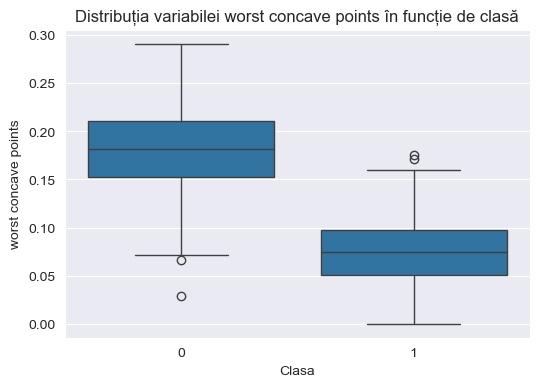

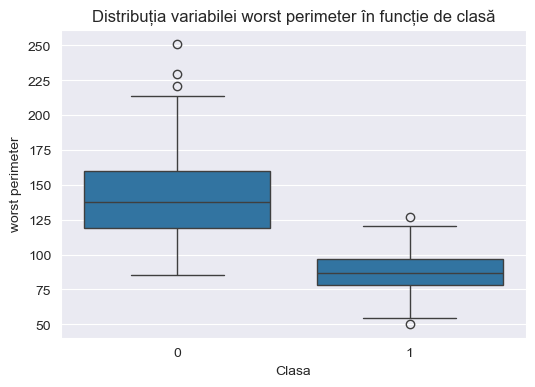

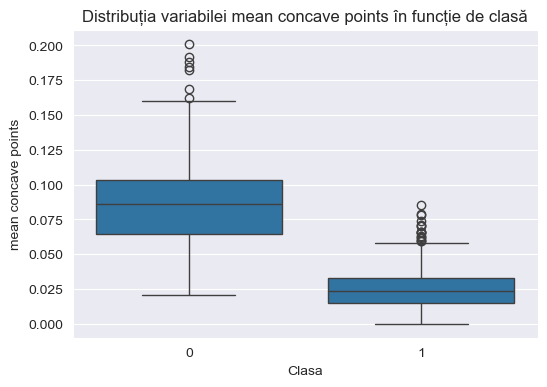

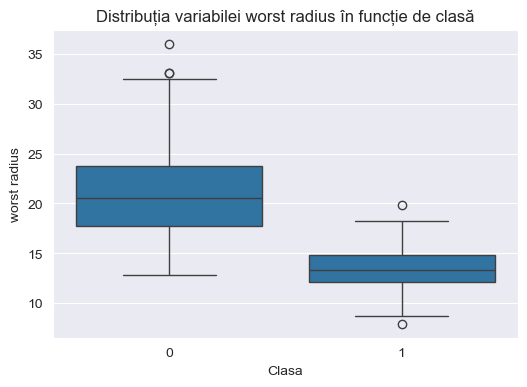

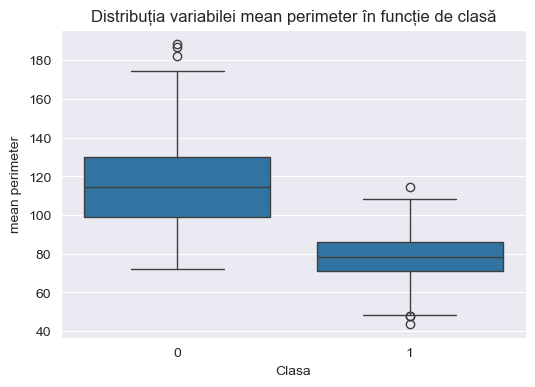

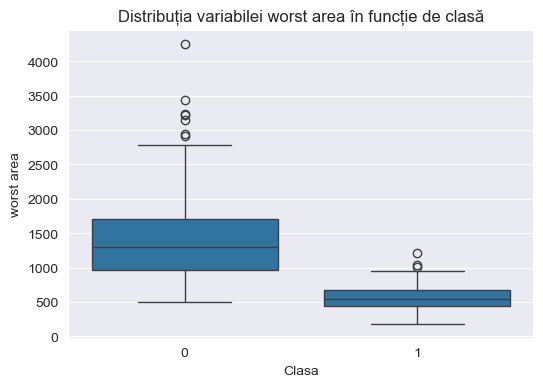

In [12]:
for col in top_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x="target", y=col)
    plt.title(f"Distribuția variabilei {col} în funcție de clasă")
    plt.xlabel("Clasa")
    plt.ylabel(col)
    plt.show()

## 3. Pregătirea datelor pentru antrenare

Dataset-ul este împărțit în date de antrenare și date de testare. Conform cerinței proiectului, folosim 75% dintre observații pentru antrenare și 25% pentru testare și validare.

Deoarece variabilele numerice au scări diferite, folosim `StandardScaler` într-un `Pipeline`. Astfel, scalarea este aplicată corect doar pe datele de antrenare și apoi reutilizată pe datele de testare, evitând data leakage.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (426, 30)
X_test: (143, 30)
y_train: (426,)
y_test: (143,)


## 4. Antrenarea și compararea modelelor de bază

În această etapă sunt antrenate toate modelele de clasificare propuse în cerința proiectului, folosind valorile implicite ale hiperparametrilor. Pentru fiecare model se calculează metricile: acuratețe, precizie, recall, scor F1 și ROC-AUC.

In [16]:
classification_models = get_classification_models(random_state=42)

classification_models.keys()

dict_keys(['Naive Bayes', 'Logistic Regression', 'Decision Tree', 'Random Forest', 'Support Vector Machine', 'K-Nearest Neighbors', 'XGBoost', 'CatBoost', 'Explainable Boosting Machine'])

In [17]:
classification_results = {}
trained_classification_models = {}

models_that_need_scaling = [
    "Naive Bayes",
    "Logistic Regression",
    "Support Vector Machine",
    "K-Nearest Neighbors"
]

for model_name, model in classification_models.items():
    print(f"Training: {model_name}")

    if model_name in models_that_need_scaling:
        final_model = Pipeline([
            ("scaler", StandardScaler()),
            ("model", model)
        ])
    else:
        final_model = model

    final_model.fit(X_train, y_train)

    metrics = evaluate_classification_model(
        final_model,
        X_test,
        y_test
    )

    classification_results[model_name] = metrics
    trained_classification_models[model_name] = final_model

Training: Naive Bayes
Training: Logistic Regression
Training: Decision Tree
Training: Random Forest
Training: Support Vector Machine
Training: K-Nearest Neighbors
Training: XGBoost
Training: CatBoost
Training: Explainable Boosting Machine


In [18]:
classification_results_df = classification_results_to_dataframe(
    classification_results
)

classification_results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.986014,0.988889,0.988889,0.988889,0.997694
1,K-Nearest Neighbors,0.979021,0.967742,1.000000,0.983607,0.984486
2,Support Vector Machine,0.979021,0.988764,0.977778,0.983240,0.996855
3,CatBoost,0.965035,0.956989,0.988889,0.972678,0.996436
4,XGBoost,0.965035,0.956989,0.988889,0.972678,0.994549
5,Explainable Boosting Machine,0.965035,0.956989,0.988889,0.972678,0.994130
6,Random Forest,0.958042,0.956522,0.977778,0.967033,0.994969
7,Naive Bayes,0.937063,0.935484,0.966667,0.950820,0.987841
8,Decision Tree,0.923077,0.954023,0.922222,0.937853,0.923375


In [19]:
top_5_classification_models = classification_results_df.head(5)

top_5_classification_models

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.986014,0.988889,0.988889,0.988889,0.997694
1,K-Nearest Neighbors,0.979021,0.967742,1.000000,0.983607,0.984486
2,Support Vector Machine,0.979021,0.988764,0.977778,0.983240,0.996855
3,CatBoost,0.965035,0.956989,0.988889,0.972678,0.996436
4,XGBoost,0.965035,0.956989,0.988889,0.972678,0.994549


### Interpretarea rezultatelor modelelor de bază

În urma antrenării modelelor de bază, observăm diferențe între algoritmi în ceea ce privește acuratețea, precizia, recall-ul, scorul F1 și ROC-AUC. Pentru această problemă, scorul F1 este foarte relevant deoarece combină precizia și recall-ul, oferind o imagine mai echilibrată asupra performanței modelului.

Primele 5 modele vor fi selectate pentru etapa următoare, în care se va realiza ajustarea hiperparametrilor. Scopul acestei etape este verificarea posibilității de îmbunătățire a performanței modelelor prin alegerea unor combinații mai bune de hiperparametri.

In [20]:
top_5_model_names = top_5_classification_models["Model"].tolist()

top_5_model_names

['Logistic Regression',
 'K-Nearest Neighbors',
 'Support Vector Machine',
 'CatBoost',
 'XGBoost']

## 5. Ajustarea hiperparametrilor

În această etapă sunt ajustați hiperparametrii pentru primele 5 modele obținute în etapa de antrenare de bază. Pentru modelele sensibile la scalarea datelor, precum Logistic Regression, K-Nearest Neighbors și Support Vector Machine, folosim `Pipeline` cu `StandardScaler`. Pentru CatBoost și XGBoost, modelele sunt antrenate direct, deoarece metodele bazate pe boosting nu necesită standardizarea variabilelor.

In [21]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

In [22]:
tuning_configs = {
    "Logistic Regression": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", classification_models["Logistic Regression"])
        ]),
        "params": {
            "model__C": [0.01, 0.1, 1, 10, 100],
            "model__solver": ["liblinear", "lbfgs"]
        }
    },

    "K-Nearest Neighbors": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", classification_models["K-Nearest Neighbors"])
        ]),
        "params": {
            "model__n_neighbors": [3, 5, 7, 9, 11],
            "model__weights": ["uniform", "distance"],
            "model__metric": ["euclidean", "manhattan"]
        }
    },

    "Support Vector Machine": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", classification_models["Support Vector Machine"])
        ]),
        "params": {
            "model__C": [0.1, 1, 10, 100],
            "model__kernel": ["linear", "rbf"],
            "model__gamma": ["scale", "auto"]
        }
    },

    "CatBoost": {
        "model": classification_models["CatBoost"],
        "params": {
            "depth": [3, 4, 5],
            "learning_rate": [0.01, 0.05, 0.1],
            "iterations": [100, 200]
        }
    },

    "XGBoost": {
        "model": classification_models["XGBoost"],
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [3, 4, 5],
            "learning_rate": [0.01, 0.05, 0.1],
            "subsample": [0.8, 1.0]
        }
    }
}

In [23]:
from catboost import CatBoostClassifier
from itertools import product

tuned_classification_results = {}
tuned_classification_models = {}
best_params_by_model = {}

for model_name in top_5_model_names:
    print(f"Tuning: {model_name}")

    config = tuning_configs[model_name]

    if model_name == "CatBoost":
        best_score = -1
        best_model = None
        best_params = None

        param_grid = config["params"]

        for depth, learning_rate, iterations in product(
            param_grid["depth"],
            param_grid["learning_rate"],
            param_grid["iterations"]
        ):
            model = CatBoostClassifier(
                depth=depth,
                learning_rate=learning_rate,
                iterations=iterations,
                verbose=0,
                random_state=42
            )

            model.fit(X_train, y_train)

            metrics = evaluate_classification_model(
                model,
                X_test,
                y_test
            )

            score = metrics["F1 Score"]

            if score > best_score:
                best_score = score
                best_model = model
                best_params = {
                    "depth": depth,
                    "learning_rate": learning_rate,
                    "iterations": iterations
                }

        metrics = evaluate_classification_model(
            best_model,
            X_test,
            y_test
        )

        tuned_classification_results[model_name] = metrics
        tuned_classification_models[model_name] = best_model
        best_params_by_model[model_name] = best_params

        print("Best params:", best_params)
        print("Best F1 score:", best_score)
        print()

    else:
        grid_search = GridSearchCV(
            estimator=config["model"],
            param_grid=config["params"],
            scoring="f1",
            cv=5,
            n_jobs=-1
        )

        grid_search.fit(X_train, y_train)

        best_model = grid_search.best_estimator_

        metrics = evaluate_classification_model(
            best_model,
            X_test,
            y_test
        )

        tuned_classification_results[model_name] = metrics
        tuned_classification_models[model_name] = best_model
        best_params_by_model[model_name] = grid_search.best_params_

        print("Best params:", grid_search.best_params_)
        print("Best CV score:", grid_search.best_score_)
        print()

Tuning: Logistic Regression
Best params: {'model__C': 0.1, 'model__solver': 'lbfgs'}
Best CV score: 0.981648570070074

Tuning: K-Nearest Neighbors
Best params: {'model__metric': 'euclidean', 'model__n_neighbors': 9, 'model__weights': 'uniform'}
Best CV score: 0.974166619773514

Tuning: Support Vector Machine
Best params: {'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'linear'}
Best CV score: 0.9741712631432258

Tuning: CatBoost
Best params: {'depth': 5, 'learning_rate': 0.01, 'iterations': 200}
Best F1 score: 0.978021978021978

Tuning: XGBoost
Best params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
Best CV score: 0.9721130799112452



In [24]:
tuned_classification_results_df = classification_results_to_dataframe(
    tuned_classification_results
)

tuned_classification_results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Support Vector Machine,0.986014,0.988889,0.988889,0.988889,0.996436
1,XGBoost,0.979021,0.967742,1.000000,0.983607,0.995807
2,Logistic Regression,0.979021,0.978022,0.988889,0.983425,0.997065
3,CatBoost,0.972028,0.967391,0.988889,0.978022,0.995178
4,K-Nearest Neighbors,0.965035,0.947368,1.000000,0.972973,0.992977


In [25]:
best_classification_model_name = tuned_classification_results_df.iloc[0]["Model"]
best_classification_model = tuned_classification_models[best_classification_model_name]

best_classification_model_name

'Support Vector Machine'

In [26]:
best_params_by_model

{'Logistic Regression': {'model__C': 0.1, 'model__solver': 'lbfgs'},
 'K-Nearest Neighbors': {'model__metric': 'euclidean',
  'model__n_neighbors': 9,
  'model__weights': 'uniform'},
 'Support Vector Machine': {'model__C': 0.1,
  'model__gamma': 'scale',
  'model__kernel': 'linear'},
 'CatBoost': {'depth': 5, 'learning_rate': 0.01, 'iterations': 200},
 'XGBoost': {'learning_rate': 0.1,
  'max_depth': 4,
  'n_estimators': 200,
  'subsample': 0.8}}

### Interpretarea rezultatelor după ajustarea hiperparametrilor

După ajustarea hiperparametrilor, modelele din top 5 au fost reevaluate pe setul de testare. Scopul acestei etape a fost îmbunătățirea performanței și reducerea riscului de overfitting prin alegerea unor valori mai potrivite pentru hiperparametri.
Modelul cu cea mai bună performanță după tuning va fi folosit ca reper principal în etapele următoare. Totuși, diferențele dintre modele trebuie analizate nu doar printr-o singură metrică, ci prin ansamblul valorilor obținute pentru accuracy, precision, recall, F1 și ROC-AUC.

<Figure size 600x500 with 0 Axes>

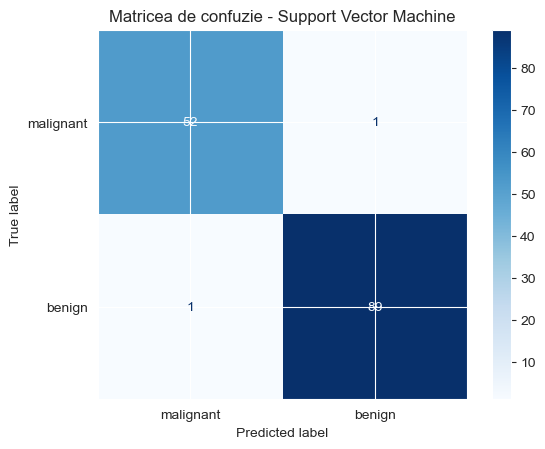

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred_best = best_classification_model.predict(X_test)

plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best,
    display_labels=["malignant", "benign"],
    cmap="Blues"
)
plt.title(f"Matricea de confuzie - {best_classification_model_name}")
plt.show()

Matricea de confuzie permite observarea numărului de predicții corecte și incorecte pentru fiecare clasă. În această problemă, este important să analizăm în special cazurile în care o tumoră malignă ar putea fi clasificată greșit ca benignă, deoarece acest tip de eroare poate avea consecințe practice semnificative.

## 6. Curbele de învățare

Curbele de învățare sunt folosite pentru a analiza modul în care performanța modelului se modifică atunci când crește dimensiunea setului de antrenare. Acestea permit identificarea unor posibile situații de overfitting sau underfitting.

Dacă scorul de antrenare este foarte mare, iar scorul de validare este mult mai mic, modelul poate suferi de overfitting. Dacă ambele scoruri sunt scăzute, modelul poate suferi de underfitting.

In [28]:
from sklearn.model_selection import learning_curve

In [29]:
def plot_learning_curve(model, X, y, model_name):
    train_sizes, train_scores, validation_scores = learning_curve(
        estimator=model,
        X=X,
        y=y,
        train_sizes=np.linspace(0.1, 1.0, 5),
        cv=5,
        scoring="f1",
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)

    validation_mean = validation_scores.mean(axis=1)
    validation_std = validation_scores.std(axis=1)

    plt.figure(figsize=(7, 5))

    plt.plot(train_sizes, train_mean, marker="o", label="Scor antrenare")
    plt.plot(train_sizes, validation_mean, marker="o", label="Scor validare")

    plt.fill_between(
        train_sizes,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.15
    )

    plt.fill_between(
        train_sizes,
        validation_mean - validation_std,
        validation_mean + validation_std,
        alpha=0.15
    )

    plt.title(f"Curba de învățare - {model_name}")
    plt.xlabel("Număr de exemple de antrenare")
    plt.ylabel("F1 Score")
    plt.legend()
    plt.grid(True)
    plt.show()

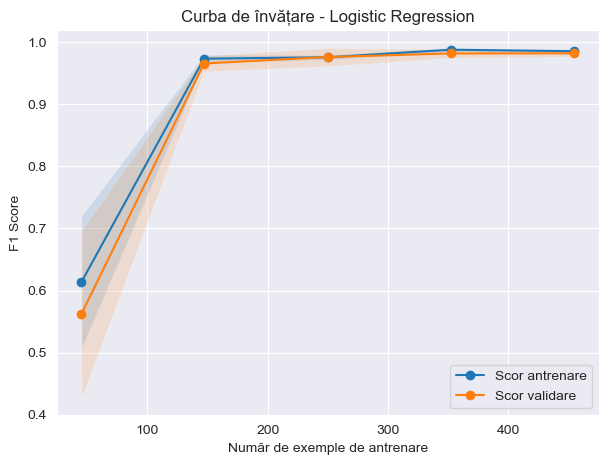

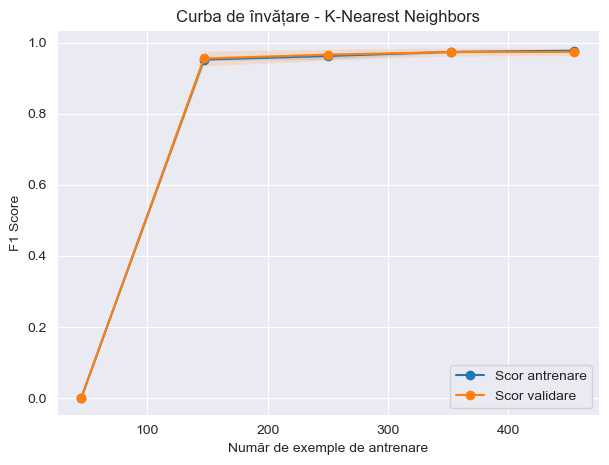

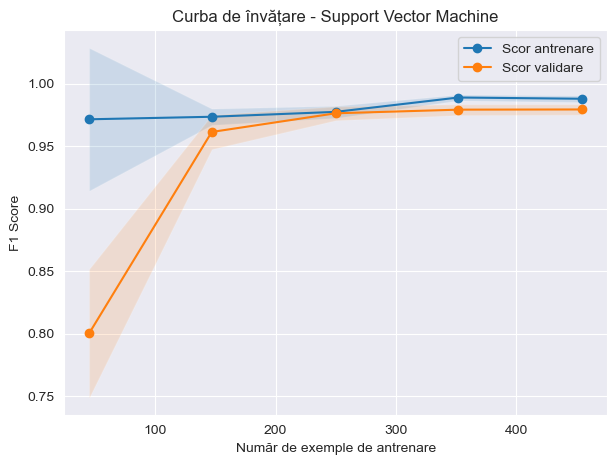

CatBoost este sărit aici din cauza incompatibilității cu learning_curve din scikit-learn.


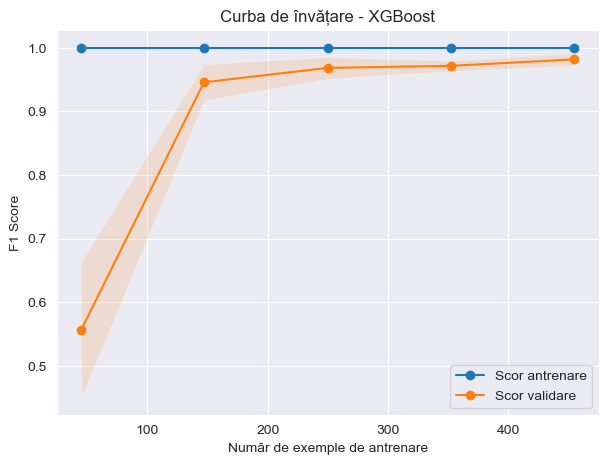

In [30]:
for model_name, model in tuned_classification_models.items():
    if model_name == "CatBoost":
        print("CatBoost este sărit aici din cauza incompatibilității cu learning_curve din scikit-learn.")
        continue

    plot_learning_curve(
        model=model,
        X=X,
        y=y,
        model_name=model_name
    )

Pentru CatBoost, curba de învățare nu a fost generată cu funcția `learning_curve` din scikit-learn din cauza unei incompatibilități între versiunea curentă de CatBoost și mecanismul intern `__sklearn_tags__` folosit de scikit-learn. Modelul CatBoost a fost totuși antrenat, evaluat și comparat cu celelalte modele.

In [31]:
top_3_tuned_model_names = tuned_classification_results_df.head(3)["Model"].tolist()

top_3_tuned_model_names

['Support Vector Machine', 'XGBoost', 'Logistic Regression']

TreeExplainer → pentru XGBoost, Random Forest, Decision Tree, CatBoost

LinearExplainer → pentru Logistic Regression

KernelExplainer / Explainer → pentru SVM sau KNN

In [32]:
top_3_tuned_model_names

['Support Vector Machine', 'XGBoost', 'Logistic Regression']

In [33]:
for model_name in top_3_tuned_model_names:
    print(model_name)

Support Vector Machine
XGBoost
Logistic Regression


## 7. Explicabilitatea modelelor folosind SHAP

În această etapă sunt analizate primele 3 modele perfecționate folosind SHAP. Scopul este înțelegerea modului în care caracteristicile de intrare influențează predicțiile modelelor, atât la nivel global, cât și local.

Analiza SHAP permite identificarea celor mai importante caracteristici și explicarea contribuției acestora asupra rezultatului prezis.

In [35]:
import shap

shap.initjs()

In [36]:
X_train_sample = X_train.sample(n=min(100, len(X_train)), random_state=42)
X_test_sample = X_test.sample(n=min(50, len(X_test)), random_state=42)

y_test_sample = y_test.loc[X_test_sample.index]

In [37]:
def get_model_and_transformed_data(model, X_background, X_explain):
    """
    Dacă modelul este Pipeline, aplică scaler-ul și returnează modelul final.
    Dacă nu este Pipeline, returnează modelul direct și datele nemodificate.
    """

    if isinstance(model, Pipeline):
        preprocessor = model.named_steps["scaler"]
        final_model = model.named_steps["model"]

        X_background_transformed = preprocessor.transform(X_background)
        X_explain_transformed = preprocessor.transform(X_explain)

        X_background_transformed = pd.DataFrame(
            X_background_transformed,
            columns=X_background.columns,
            index=X_background.index
        )

        X_explain_transformed = pd.DataFrame(
            X_explain_transformed,
            columns=X_explain.columns,
            index=X_explain.index
        )

        return final_model, X_background_transformed, X_explain_transformed

    return model, X_background, X_explain

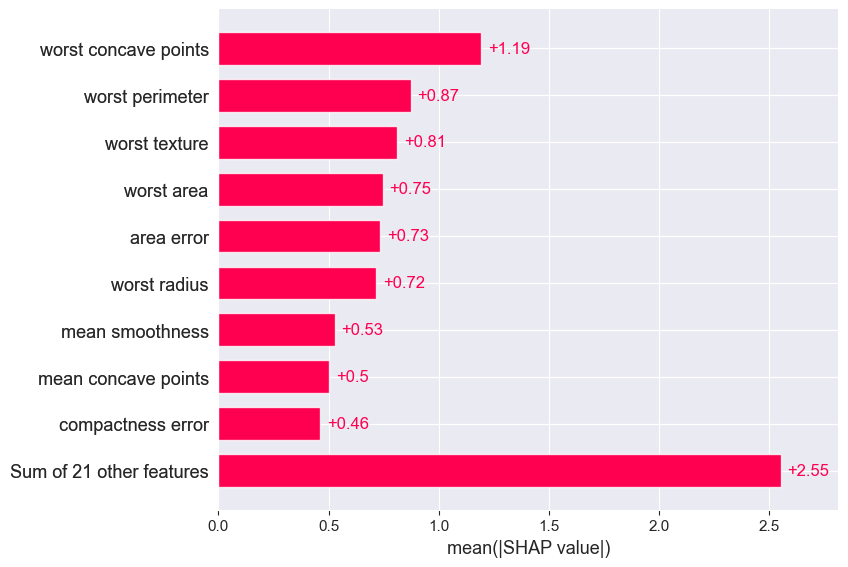

In [38]:
xgb_model = tuned_classification_models["XGBoost"]

xgb_explainer = shap.TreeExplainer(xgb_model)
xgb_shap_values = xgb_explainer(X_test_sample)

shap.plots.bar(xgb_shap_values, max_display=10)

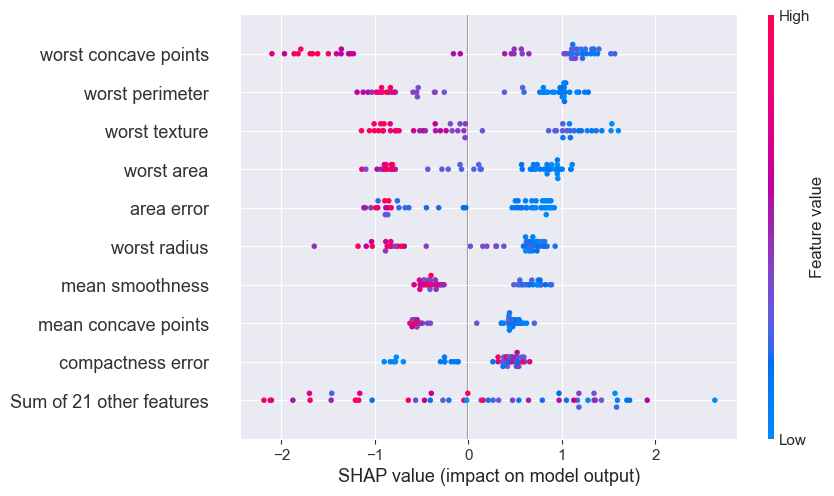

In [39]:
shap.plots.beeswarm(xgb_shap_values, max_display=10)

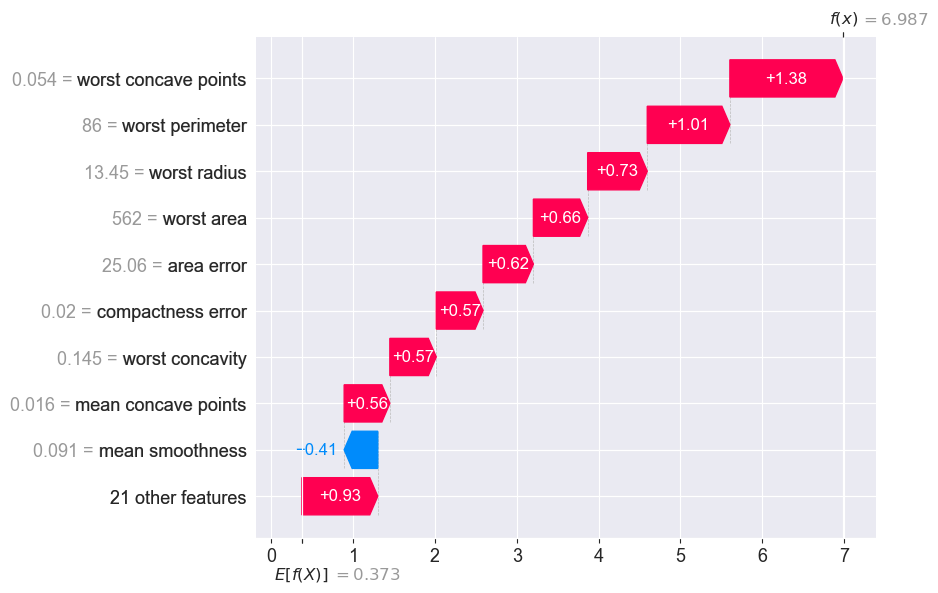

In [40]:
shap.plots.waterfall(xgb_shap_values[0], max_display=10)

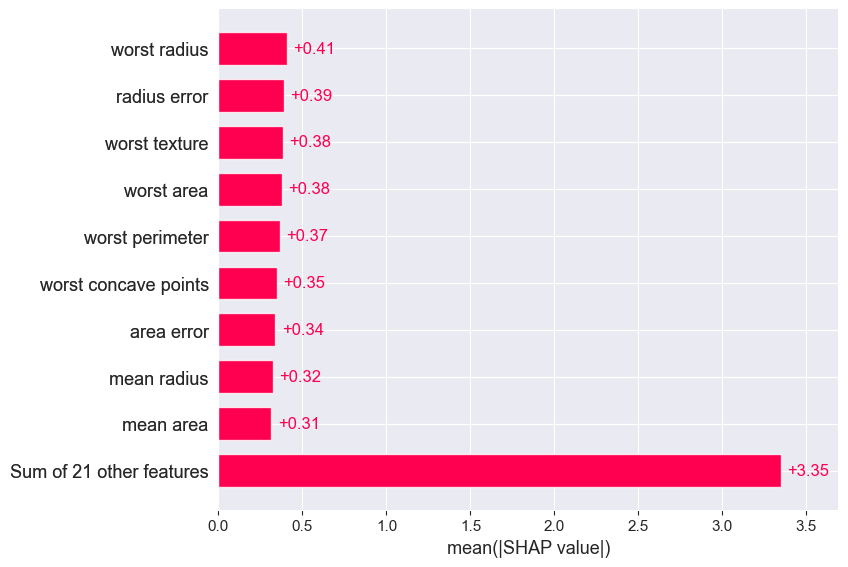

In [41]:
logreg_model = tuned_classification_models["Logistic Regression"]

logreg_final_model, logreg_background, logreg_explain = get_model_and_transformed_data(
    logreg_model,
    X_train_sample,
    X_test_sample
)

logreg_explainer = shap.LinearExplainer(
    logreg_final_model,
    logreg_background
)

logreg_shap_values = logreg_explainer(logreg_explain)

shap.plots.bar(logreg_shap_values, max_display=10)

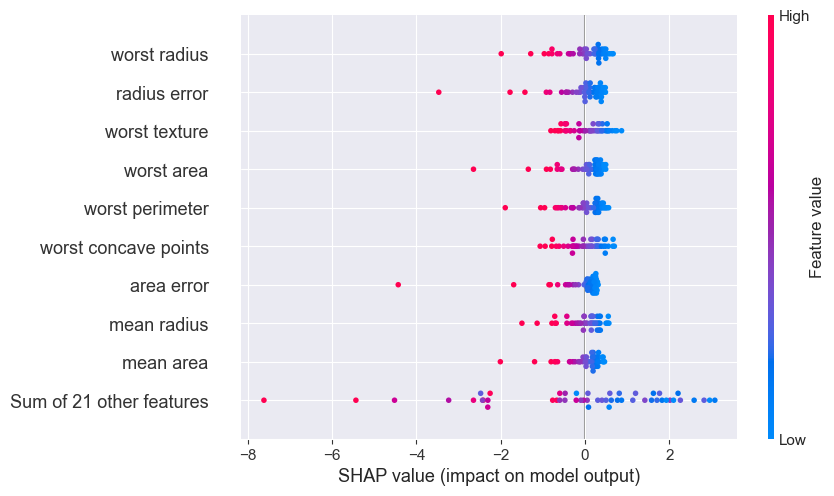

In [42]:
shap.plots.beeswarm(logreg_shap_values, max_display=10)

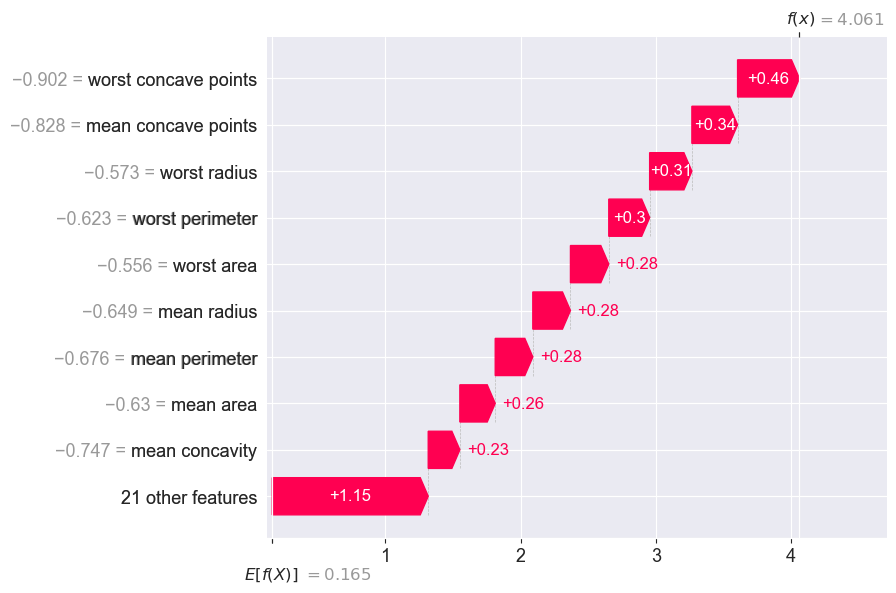

In [43]:
shap.plots.waterfall(logreg_shap_values[0], max_display=10)

In [44]:
svm_model = tuned_classification_models["Support Vector Machine"]

svm_final_model, svm_background, svm_explain = get_model_and_transformed_data(
    svm_model,
    X_train_sample,
    X_test_sample
)

svm_explainer = shap.KernelExplainer(
    svm_final_model.predict_proba,
    svm_background
)

svm_shap_values = svm_explainer.shap_values(
    svm_explain,
    nsamples=100
)

  0%|          | 0/50 [00:00<?, ?it/s]

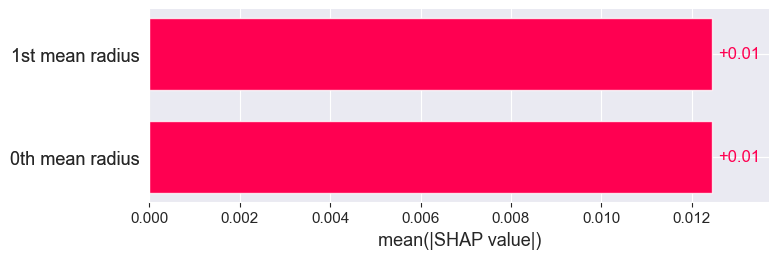

In [45]:
svm_shap_class_1 = shap.Explanation(
    values=svm_shap_values[1],
    base_values=np.repeat(svm_explainer.expected_value[1], svm_explain.shape[0]),
    data=svm_explain.values,
    feature_names=svm_explain.columns.tolist()
)

shap.plots.bar(svm_shap_class_1, max_display=10)

In [46]:
type(svm_shap_values), np.array(svm_shap_values).shape

(numpy.ndarray, (50, 30, 2))

In [47]:
svm_values_array = np.array(svm_shap_values)

svm_values_class_1 = svm_values_array[:, :, 1]

svm_shap_class_1 = shap.Explanation(
    values=svm_values_class_1,
    base_values=np.repeat(
        svm_explainer.expected_value[1],
        svm_explain.shape[0]
    ),
    data=svm_explain.values,
    feature_names=svm_explain.columns.tolist()
)

svm_shap_class_1.values.shape, svm_explain.shape

((50, 30), (50, 30))

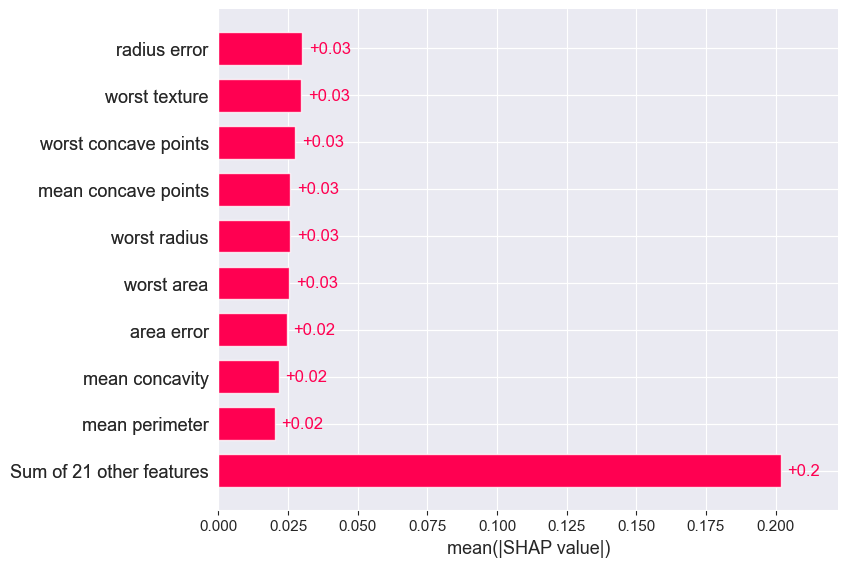

In [48]:
shap.plots.bar(svm_shap_class_1, max_display=10)

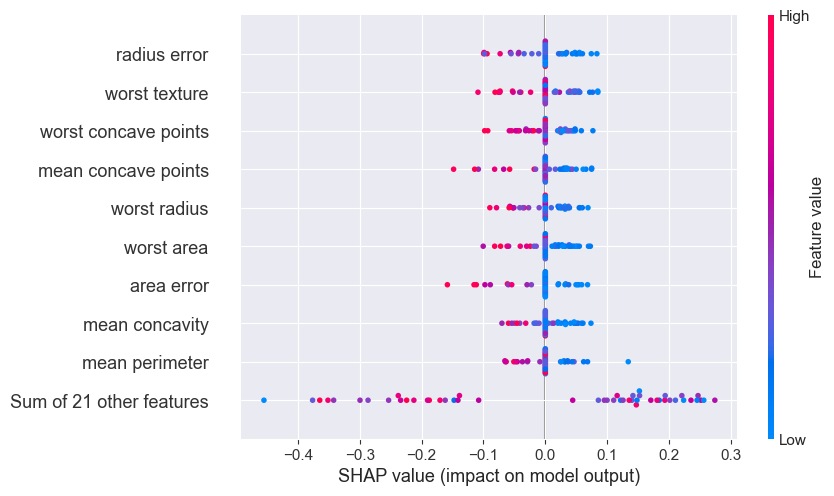

In [49]:
shap.plots.beeswarm(svm_shap_class_1, max_display=10)

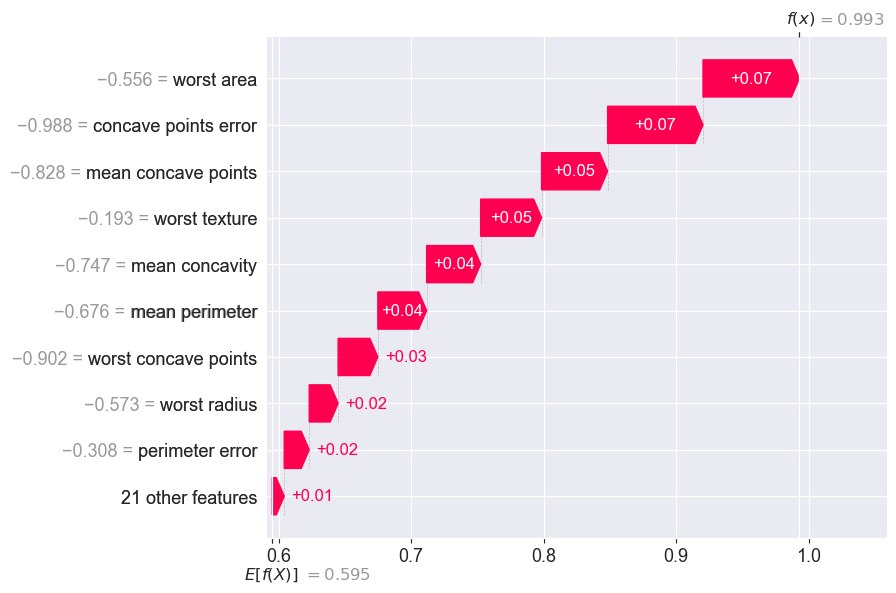

In [50]:
shap.plots.waterfall(svm_shap_class_1[0], max_display=10)

### Interpretarea analizei SHAP pentru clasificare

Analiza SHAP a fost utilizată pentru interpretarea primelor 3 modele perfecționate. Graficele de tip bar plot evidențiază importanța globală a caracteristicilor, iar graficele beeswarm arată atât importanța variabilelor, cât și direcția influenței acestora asupra predicției.

Waterfall plot-ul oferă o explicație locală pentru o predicție individuală, arătând ce caracteristici au contribuit cel mai mult la rezultatul prezis de model.

Valorile SHAP pozitive împing predicția către clasa pozitivă, iar valorile SHAP negative împing predicția în direcția opusă. Astfel, analiza SHAP permite înțelegerea modului în care modelul ia decizii, nu doar evaluarea performanței sale numerice.

In [51]:
import joblib
from pathlib import Path

models_dir = PROJECT_ROOT / "models" / "classification"
tables_dir = PROJECT_ROOT / "reports" / "tables"

models_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

for model_name, model in tuned_classification_models.items():
    safe_name = model_name.lower().replace(" ", "_").replace("-", "_")
    joblib.dump(model, models_dir / f"{safe_name}.joblib")

classification_results_df.to_csv(
    tables_dir / "classification_base_results.csv",
    index=False
)

tuned_classification_results_df.to_csv(
    tables_dir / "classification_tuned_results.csv",
    index=False
)

joblib.dump(
    best_params_by_model,
    tables_dir / "classification_best_params.joblib"
)

print("Modelele și rezultatele pentru clasificare au fost salvate.")

Modelele și rezultatele pentru clasificare au fost salvate.


## 8. Concluzii pentru problema de clasificare

În cadrul problemei de clasificare au fost analizate mai multe modele de machine learning, pornind de la variantele de bază și continuând cu ajustarea hiperparametrilor pentru primele 5 modele. Modelele au fost evaluate folosind metrici specifice clasificării: acuratețe, precizie, recall, scor F1, ROC-AUC și matricea de confuzie.

După etapa de tuning, cel mai bun model a fost selectat pe baza scorului F1. Acest scor este potrivit pentru problema de clasificare deoarece combină precizia și recall-ul, oferind o imagine echilibrată asupra performanței.

Curbele de învățare au fost folosite pentru a analiza comportamentul modelelor în raport cu dimensiunea setului de antrenare, iar analiza SHAP a oferit o interpretare asupra caracteristicilor care influențează cel mai mult predicțiile.

Astfel, analiza de clasificare include atât compararea numerică a modelelor, cât și interpretarea comportamentului acestora, conform cerințelor proiectului.